Ergebnisse visualisieren

Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Plots

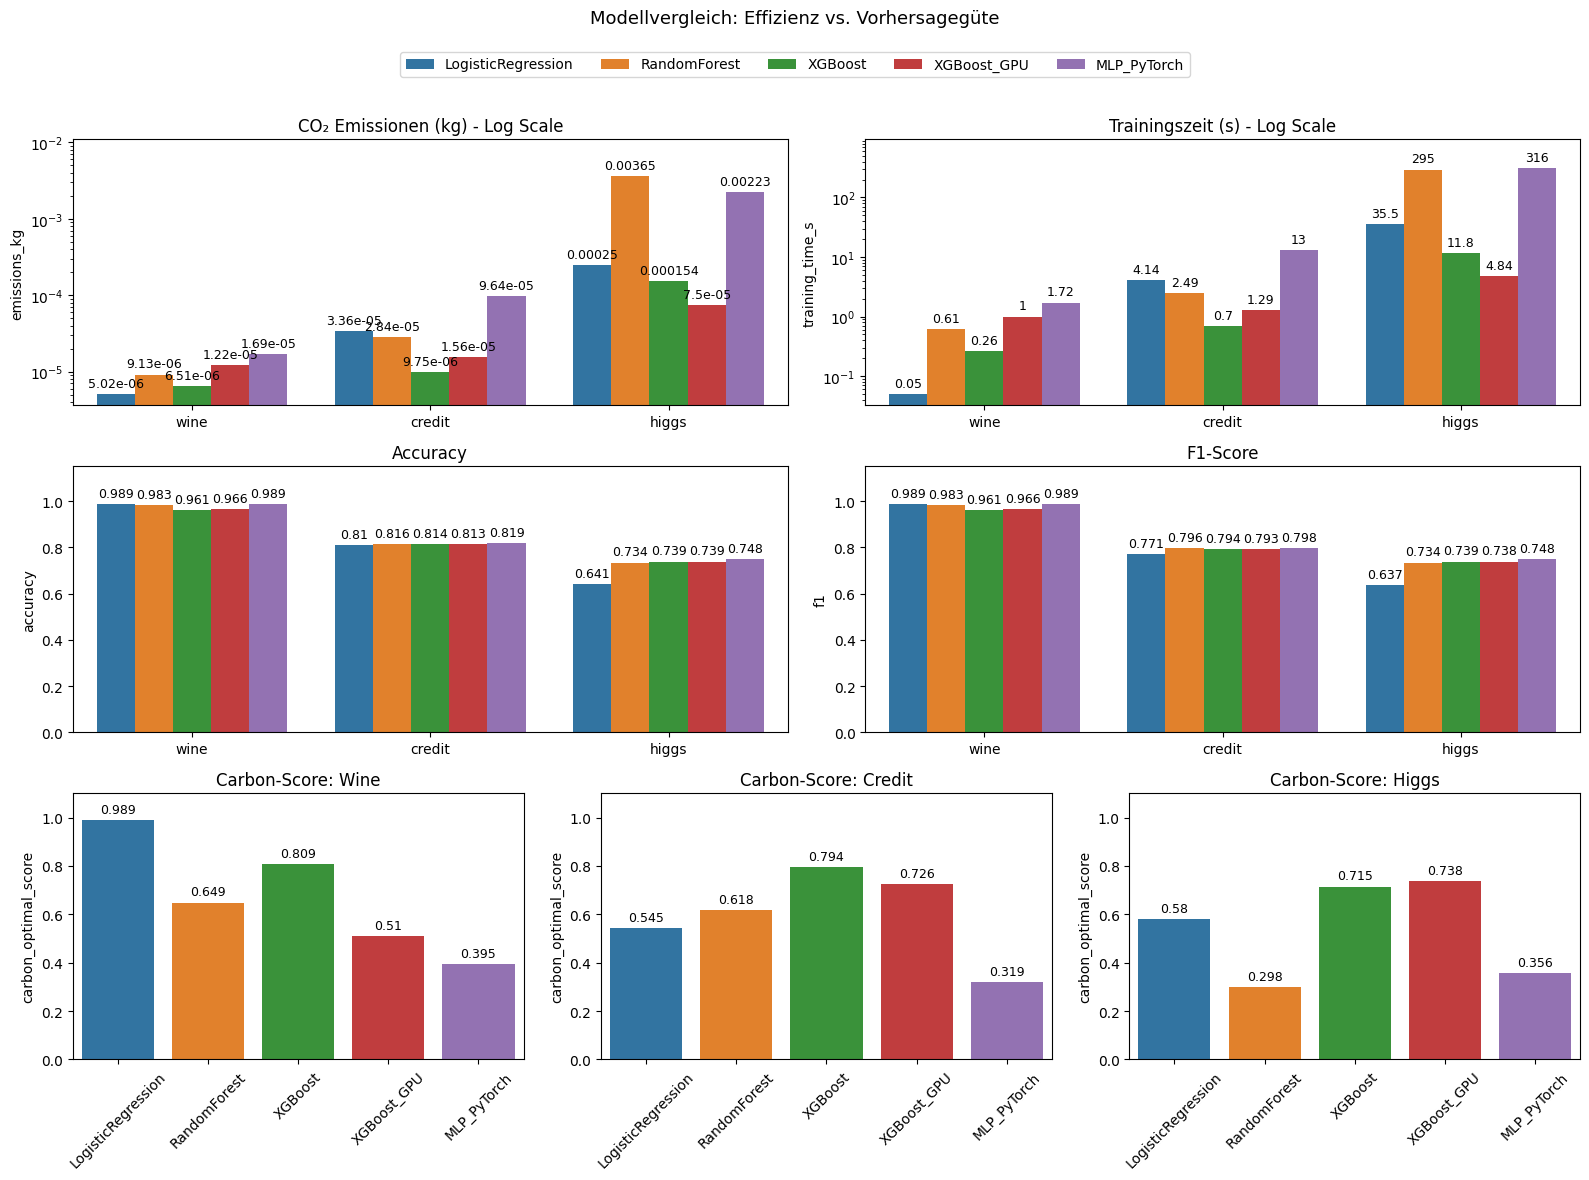

In [2]:
df = pd.read_csv("../results/results.csv")

df = df[["timestamp", "model", "dataset", "nrows", "accuracy", "f1", "emissions_kg", "training_time_s"]]

df = df.drop_duplicates(subset=["dataset", "nrows", "model"], keep="last")

# l_1 gibt der Trainingszeit etwas weniger Gewicht während l_2 die emissions mit voller Gewichtung betrachtet.
# so soll ein langsames Modell was aber nicht so viel verbraucht nicht so hart bestraft werden wie eins was einfach viel CO2 ausschüttet 
l_1 = 0.5
l_2 = 1

min_time = df.groupby('dataset')['training_time_s'].transform('min')
max_time = df.groupby('dataset')['training_time_s'].transform('max')
df['time_scaled'] = (df['training_time_s'] - min_time) / (max_time - min_time)

min_co2 = df.groupby('dataset')['emissions_kg'].transform('min')
max_co2 = df.groupby('dataset')['emissions_kg'].transform('max')
df['co2_scaled'] = (df['emissions_kg'] - min_co2) / (max_co2 - min_co2)

df["carbon_optimal_score"] = df["f1"] / (1 + l_1 * df["time_scaled"] + l_2 * df["co2_scaled"])

# Das Problem damit ist dass die Scores erst im Nachhinein jetzt im Notebook berechnet werden. Das müsste vielleicht geändert werden dass 
# es die Normalisierung etc. während des durchlaufens von run_all.py macht. Muss ich aber gucken wie das geht. Weil ich müsste die ja dann
# live normalisieren jedes mal wenn ein neuer wert rein kommt.
layout = [
    ["emissions", "emissions", "emissions", "time", "time", "time"],
    ["acc", "acc", "acc", "f1", "f1", "f1"],
    ["carb_wine", "carb_wine", "carb_credit", "carb_credit", "carb_higgs", "carb_higgs"]
]

fig, axes = plt.subplot_mosaic(layout, figsize=(16, 12))
fig.suptitle("Modellvergleich: Effizienz vs. Vorhersagegüte", fontsize=13)

sns.barplot(data=df, x="dataset", y="emissions_kg", hue="model", ax=axes["emissions"])
axes["emissions"].set_title("CO₂ Emissionen (kg) - Log Scale")
axes["emissions"].set_yscale("log")
axes["emissions"].set_xlabel("")
axes["emissions"].set_ylim(top=df["emissions_kg"].max() * 3)

sns.barplot(data=df, x="dataset", y="training_time_s", hue="model", ax=axes["time"])
axes["time"].set_title("Trainingszeit (s) - Log Scale")
axes["time"].set_yscale("log")
axes["time"].set_xlabel("")
axes["time"].set_ylim(top=df["training_time_s"].max() * 3)

sns.barplot(data=df, x="dataset", y="accuracy", hue="model", ax=axes["acc"])
axes["acc"].set_title("Accuracy")
axes["acc"].set_ylim(0, 1.15)
axes["acc"].set_xlabel("")

sns.barplot(data=df, x="dataset", y="f1", hue="model", ax=axes["f1"])
axes["f1"].set_title("F1-Score")
axes["f1"].set_ylim(0, 1.15)
axes["f1"].set_xlabel("")

datasets = ["wine", "credit", "higgs"]
carb_keys = ["carb_wine", "carb_credit", "carb_higgs"]

for ds, key in zip(datasets, carb_keys):
    subset = df[df["dataset"] == ds]
    sns.barplot(data=subset, x="model", y="carbon_optimal_score", hue="model", ax=axes[key], dodge=False)
    axes[key].set_title(f"Carbon-Score: {ds.capitalize()}")
    axes[key].set_xlabel("")
    axes[key].set_ylim(0, 1.1)
    axes[key].tick_params(axis='x', rotation=45)

for name, ax in axes.items():
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3g", padding=3, fontsize=9)
    
    # Remove EVERY individual legend inside the subplots
    if ax.get_legend():
        ax.get_legend().remove()

# Create one master legend for the entire figure at the top center
handles, labels = axes["emissions"].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=5, fontsize=10, title=None)

# Adjust the top margin so the title and master legend don't overlap
plt.tight_layout(rect=[0, 0, 1, 0.93]) 
plt.savefig("../results/vergleich.png", dpi=150, bbox_inches="tight")
plt.show()